# Model Factory — what I worked on

**Jeffrey Stall (jstall)** · CSED 504 · Part 1 (A1 Computer Vision)

## 1. Summary

This is my summary of what I contributed, what I decided along the way, and what I actually learned
from it. It is deliberately about the *process* rather than the model math.  I set out to build a
**model factory**: the tooling to train and evaluate models efficiently, so that part 2 can be about
the harder problem instead of about fighting the plumbing. That was the goal in our
[original proposal](https://docs.google.com/document/d/1zP7TbLEXAUgCuIkICG1_eT-bb0IjNyJxVdL3mipfwuQ/edit?tab=t.0#heading=h.5x0d5h95i329),
and one of the primary areas I focused on:

1. I deliberately did *not* try to invent an architecture. I used CIFAR-10 and CIFAR-100 with
known-good architectures to get a baseline I could trust, then scaled the same pipeline up to
ImageNet-32 to see what breaks when the dataset gets 25× bigger.

2. Most of my time went into **performance tuning the GPUs**, because that is what decides whether
an experiment takes 4 minutes or 40 days. The headline: I took ResNet-18 training from about **4,150
images per second at 30% GPU utilization to about 21,500 at 84%**, on the same hardware. I also
examined where multiple GPUs could enable parallelism, and (surprisingly) where they could not.
These speedups is what made it practical to run the whole study, controls and all.

3. I also got a real answer to the question we set up in the first place: **when does a Transformer
actually beat a CNN?** Section 7 has the numbers.


## 2. Connecting CSED 502 to PyTorch in a production environment

In 502 we wrote everything by hand in numpy: the forward pass, the backward pass, a `Solver` class,
and `np.random.choice` to grab a batch. Moving to PyTorch, I wanted to keep that mental model rather
than treat the framework as a black box, so I mapped the pieces one to one:

| CSED 502 (numpy, by hand) | this project (PyTorch) |
|---|---|
| `Solver._step()` | `train_one_epoch()` in [`train_loop.py`](train_loop.py) |
| hand-written backward pass | `loss.backward()` — autograd builds the graph for us |
| `np.random.choice(num_train, batch_size)` | a fresh permutation each epoch, so every image is seen exactly once |
| a loop over a numpy array | a loader that keeps the data on the GPU and hands back augmented batches |

**Where I used AI:** I used it to translate the 502 concepts into the PyTorch idiom and, more usefully,
to tell me what PyTorch was now doing *implicitly* that I used to do by hand: optimizer state,
scheduler stepping, and where autograd inserts itself. That mapping is what let me trust the code
instead of copying it.

**What I learned:** The mental model transfers cleanly, but the *performance* model does not. In 502
the arithmetic was the expensive part. On a GPU the arithmetic is nearly free, and the cost moves to
moving data around and to how many separate operations you ask the GPU to run. Almost every problem I
hit for the rest of the project was a version of that one idea.


## 3. CIFAR-10 and CIFAR-100 as the baseline

I started here on purpose. CIFAR is small enough to iterate on in minutes, and I already had
known-good hyperparameters from 502, so I could tell the difference between "my code is wrong" and
"this model is just hard to train."

**How I simplified:** I reused the 502 CIFAR recipe rather than tuning from scratch, and I
**parameter-matched the ViT to the ResNet** (about 11.0M against 11.7M). That was a deliberate call:
if the Transformer had been much bigger, any result would just have been "bigger model wins" and the
comparison would have been worthless.

**Where I used AI:** Porting the 502 model builders into [`models.py`](models.py), and setting up the
ViT for 32×32 images: a standard ViT chops an image into 16-pixel patches, which on a 32-pixel image
leaves almost nothing, so it needed a patch size of 4 and a matching stem.

**What I learned:**

1. **A CNN and a Transformer want different recipes.** The CNN wants SGD with momentum; the ViT wants
   AdamW and a warmup. This is not a detail: using one recipe for both would have quietly decided the
   result before the experiment ran.
2. **Augmentation is not universally good.** Mixup helps the ViT and actively *hurts* the CNN. When I
   gave the CNN the ViT's augmentation as a control, it got **worse** (33.9%, down from 36.9%).
3. **A setting that rescues one model can quietly cost another.** I added gradient clipping because
   ResNet-50 was diverging to NaN without it. It fixed ResNet-50 and cost **ResNet-18 about five
   points** (36.9% clipped against 41.7% unclipped). That one took a while to spot, because nothing
   errors: the model just quietly trains worse. Clipping now defaults off for ResNet-18 only.


## 4. Making it run on everyone's machine

Our group is spread across Windows, Mac, Linux, and Google Colab, so the pipeline had to work on all
of them or people would be blocked. I leaned on the device-detection and profiling work I had already
done for CSED 502 and 503 rather than starting over. Additional, I incorporated NVidia's performance
tools to get realtime GPU utilization information during training.

The problems that actually cost time were not the obvious ones:

- **Windows and macOS were silently running single-process data loading.** The code enabled DataLoader
  workers only when the start method was `fork`, which is Linux-only. On Windows and Mac it silently
  fell back to zero workers, so one CPU core did all the work while the GPU waited. Nothing warned us;
  it was just slow. This was the single biggest fix.
- **`channels_last` is a win or a trap depending on the precision.** Paired with bf16 it measured
  **1.34×** on an RTX 2000 Ada. Paired with fp16 it was **3.5× slower**. Same flag, opposite result.
- **Apple Silicon needs a fallback** for operations MPS has not implemented, and that fallback only
  covers the forward pass, not the backward one.
- **`torch.compile` is not available on Windows** (it needs Triton), so that whole lever was off the
  table for our main machine.

**What I improved.** Once I understood the pipeline was the bottleneck, I stopped trying to make the
data loader faster and removed it: at 32x32 the entire dataset fits in GPU memory, so I load it once
and do the augmentation on the GPU. Then I wrote [`train_fleet.py`](train_fleet.py) so a two-GPU
machine trains two models at once instead of leaving a card idle.


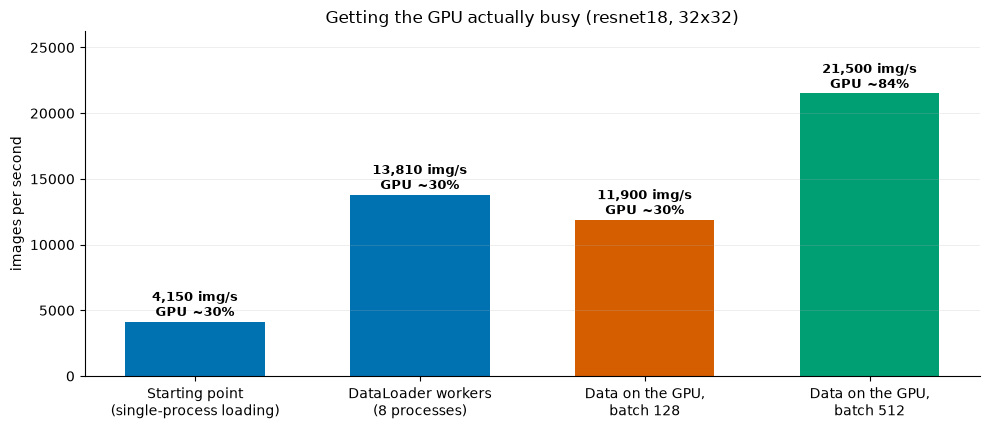

Overall: 4,150 to 21,500 img/s, about 5.2×, and GPU utilization from ~30% to ~84%.


In [1]:
# The performance story in one picture. These are the measured throughputs at each step of the
# investigation, on the workstation, training resnet18 on 32×32 images. The interesting bar is the
# third one: the step that went backwards is the one that told me what was actually wrong.
import matplotlib.pyplot as plt

# Each step, what changed, and what it measured. The utilization column is why the first number was
# so misleading: the GPU was mostly idle, so the problem was never the model.
steps = [
    ('Starting point\n(single-process loading)', 4150,  '~30%'),
    ('DataLoader workers\n(8 processes)',        13810, '~30%'),
    ('Data on the GPU,\nbatch 128',              11900, '~30%'),
    ('Data on the GPU,\nbatch 512',              21500, '~84%'),
]
labels = [s[0] for s in steps]
speeds = [s[1] for s in steps]
utils  = [s[2] for s in steps]

# Color the step that got slower differently: it is the one that falsified my assumption, and it
# deserves to stand out rather than hide in a row of blue bars.
colors = ['#0072B2', '#0072B2', '#D55E00', '#009E73']

fig, ax = plt.subplots(figsize=(10, 4.4))
bars = ax.bar(labels, speeds, color=colors, width=0.62)

# Label each bar with its throughput and the GPU utilization that went with it.
for bar, spd, u in zip(bars, speeds, utils):
    ax.annotate(f'{spd:,} img/s\nGPU {u}', xy=(bar.get_x() + bar.get_width() / 2, spd),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('images per second')
ax.set_title('Getting the GPU actually busy (resnet18, 32x32)')
ax.set_ylim(0, max(speeds) * 1.22)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print('Overall: 4,150 to 21,500 img/s, about 5.2×, and GPU utilization from ~30% to ~84%.')

**The step that taught me the most is the one that went backwards.** After adding worker
processes the GPU was *still* only about 30% busy, and I assumed it was still starving for data. So I
tested that assumption directly: I put the data and the augmentation entirely on the GPU, which makes
the data source effectively free, and measured again.

It got **slower** (11,900 against 13,810 img/s). A free data source making things slower means the
data was never the bottleneck. The real problem was that at batch 128 a small model finishes each
batch faster than the CPU can queue up the next one, so the GPU sits waiting between batches.
Raising the batch to 512 gave it enough work per launch to stay busy, and that is where the 21,500
img/s came from.

I would not have found that by guessing. I found it by making a prediction, measuring it, and being
wrong in a way that was informative. The full writeup is in
[`report_factory_performance.ipynb`](report_factory_performance.ipynb).


## 5. Scaling up to ImageNet-32

CIFAR is 50,000 images. ImageNet-32 is 1.28 million — 25× more — and it ships as JPEG images packed
inside parquet files. Decoding those on the fly would mean decoding 1.28 million JPEGs *every epoch*
on the CPU, which would have made the GPU work I had just done pointless.

**How I simplified it.** I decode the whole thing exactly **once**, up front, into a flat array of raw
bytes (3.9 GB on disk, see [`imagenet_prepare.py`](imagenet_prepare.py)). After that step, training
never touches JPEG, PIL, or parquet again — it just indexes into an array. This is not an optimization
I did for fun; it is the step that made the dataset usable at all on our hardware.

**Where I used AI.** Two places. First, writing the parquet-to-array conversion with multiple worker
processes, including a Windows-specific constraint I would not have predicted: Windows spawns fresh
processes rather than forking, so the decode function has to live at module level to be pickled to the
workers. Second, writing the sanity checks that run after the conversion.

**What I learned.**

1. **Those sanity checks earned their keep immediately.** The dataset is stored **sorted by class**, so
   the first 10,000 rows contain only a handful of the 1,000 classes. If I had taken a "quick subset"
   off the front to test with, which is exactly what I would have done, every result from it would
   have been quietly meaningless. The check proves the file is sorted and prints a warning to always
   shuffle.
2. **One-time preprocessing is worth much more than a faster inner loop.** I spent a while making the
   training step faster; converting the data once was worth more than all of it, because it removed the
   work entirely instead of speeding it up.


## 6. Splitting "fast" from "full"

By this point I had a real problem that was not technical. The notebooks had grown into a mix of
"watch it work" and "produce the actual result," and those two things want opposite settings. A
notebook that takes four hours is useless for understanding, and a notebook that trains for two epochs
produces numbers nobody should quote.

So I split them, and made the split explicit:

- **The notebooks are fast pipeline checks.** A couple of epochs on a subset, a minute or two, enough
  to watch the whole loop work end to end.
- **All real training runs from the console** — [`train_run.py`](train_run.py) for one model,
  [`train_fleet.py`](train_fleet.py) for a batch across both GPUs. Results are written to `runs/`, and
  the report notebooks read them back off disk.

This mattered for the team more than it mattered for me. A group member on a laptop can run the fast
check and understand the pipeline without a workstation; the workstation runs the fleet overnight. I
also published the eight trained models to a GitHub Release with a `load_model()` helper, so anyone can
use our results **without training anything at all**.

**Where I used AI.** Building the unified CLI, the two-GPU scheduler, and the live
[`dashboard.py`](dashboard.py) that shows both cards, per-run curves, throughput, and an ETA.

**What I learned.**

1. **The split removed a whole category of confusion.** Before it, a two-epoch smoke run had appended
   junk epochs to a real run's history and corrupted a plot. Separating the two, and giving throwaway
   runs their own names, made that impossible rather than unlikely.
2. **Making results *shareable* did more for the group's speed than any single speedup.** Publishing
   the trained models meant nobody had to reproduce an overnight run to look at a number. That was
   worth more hours than the 5x throughput win.


## 7. What I actually found: CNNs against Transformers

This is the question the factory existed to answer, and the answer is more specific than "Transformers
are better."

**CNNs win until there is enough data per class, and the Transformer only overtakes at ImageNet scale.**

- On **CIFAR-10** (5,000 images per class) the CNN leads by **7.6 points**.
- On **CIFAR-100** (500 images per class) the CNN leads by **11.7 points** — a *wider* gap.
- On **ImageNet-32** (1,281 per class, 1.28M total) the ViT finally leads, **43.0% against 41.7%**.

The middle number is the interesting one. CIFAR-10 and CIFAR-100 have **exactly the same total number
of images** (50,000). The only thing that changes is how many of them belong to each class. The
Transformer does *worse* on CIFAR-100, so what starves it is not the total amount of data — it is the
amount of data **per class**. That is a distinction I could only make because the two datasets are
matched on total size, and it is the finding I am most pleased with.

**I also checked whether I had rigged it.** The winning ViT had one advantage over the baseline CNN:
mixup. So I handed the CNN more than the ViT got and re-ran it — a bigger epoch budget barely moved it
(37.1%), and adding mixup on top made it *worse* (33.9%). Adding parameters did not explain it either:
a 2x bigger CNN and an 8x bigger ViT both landed near the same place.


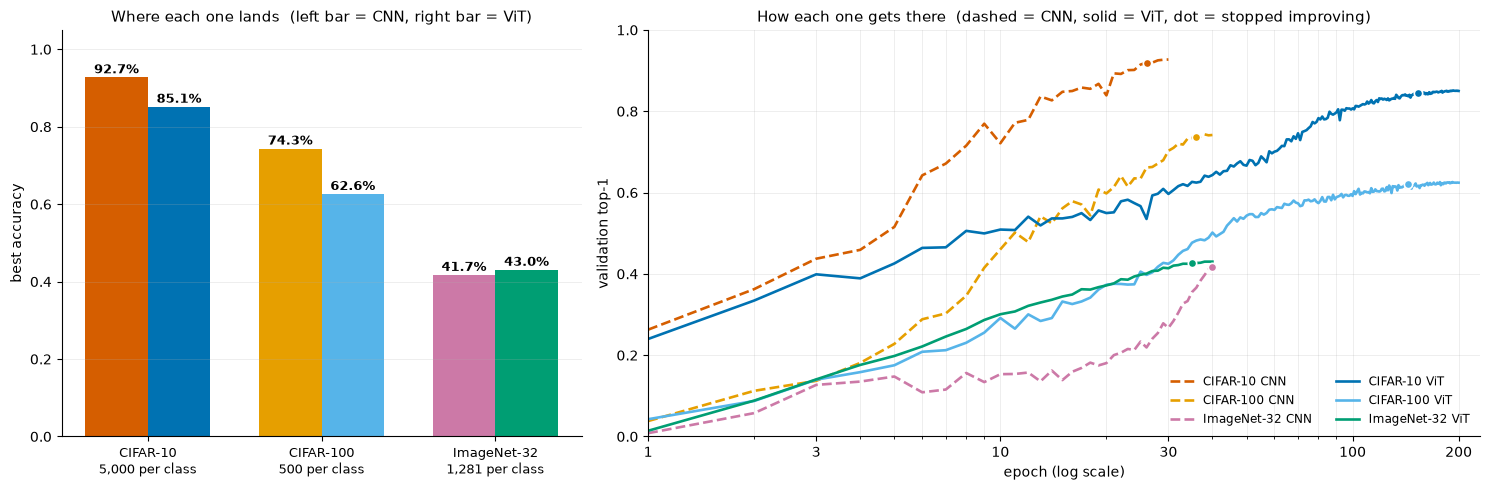

CIFAR-10  CNN 92.7% vs ViT 85.1%   CNN leads by 7.6
CIFAR-100 CNN 74.3% vs ViT 62.6%   CNN leads by 11.7  (same total data as CIFAR-10)
ImageNet  CNN 41.7% vs ViT 43.0%   ViT leads by 1.3

run                 settled at    of  epochs after
  CIFAR-10 CNN              26    30             4
  CIFAR-100 CNN             36    40             4
  ImageNet-32 CNN           40    40             0
  CIFAR-10 ViT             153   200            47
  CIFAR-100 ViT            144   200            56
  ImageNet-32 ViT           35    40             5


In [2]:
# The two charts that carry the finding. Everything here is read from the console runs on disk, so
# the numbers move when the runs do.
import json, glob, os
import matplotlib.pyplot as plt

# One color per run, shared by both charts so a bar on the left and a curve on the right are obviously
# the same thing. CNNs take the warm end and ViTs the cool end, so family still reads at a glance, and
# the set is Okabe-Ito, which stays distinguishable for the common color-vision types.
RUNS_PLOT = [
    ('cifar10_resnet18',  'CIFAR-10 CNN',    '#D55E00', '--'),
    ('cifar100_resnet18', 'CIFAR-100 CNN',   '#E69F00', '--'),
    ('resnet18_noclip',   'ImageNet-32 CNN', '#CC79A7', '--'),
    ('cifar10_vit',       'CIFAR-10 ViT',    '#0072B2', '-'),
    ('cifar100_vit',      'CIFAR-100 ViT',   '#56B4E9', '-'),
    ('vit',               'ImageNet-32 ViT', '#009E73', '-'),
]
COLOR = {tag: c for tag, _, c, _ in RUNS_PLOT}

# Pull each ImageNet-32 run's best score off disk. resnet18_noclip is the CNN we quote, because
# clipping cost the shallow ResNet about five points (section 3).
inet = {}
for path in sorted(glob.glob('runs/*_result.json')):
    tag = os.path.basename(path)[:-len('_result.json')]
    inet[tag] = json.load(open(path))['best_top1']

cnn_in = inet.get('resnet18_noclip', 0.4169)
vit_in = inet.get('vit', 0.4301)

# val_curve: one run's validation accuracy at every epoch, straight from its per-epoch log.
def val_curve(tag):
    try:
        with open(f'runs/{tag}.jsonl') as f:
            return [json.loads(line)['val']['top1'] for line in f if line.strip()]
    except OSError:
        return []

# settled_epoch: the first epoch within 1% of the run's own best, which is a far more useful mark than
# the best epoch itself. The learning rate anneals to zero, so accuracy always jumps at the very end
# and the best epoch is nearly always the last one -- marking it would say nothing. This marks where
# the curve stopped meaningfully improving, so whatever comes after it is the flat part.
def settled_epoch(ys):
    best = max(ys)
    return next(i + 1 for i, v in enumerate(ys) if v >= 0.99 * best)

# The three datasets, paired CNN against ViT, in order of how much data there is per class.
rows = [
    ('CIFAR-10\n5,000 per class',    'cifar10_resnet18',  0.9273, 'cifar10_vit',  0.8513),
    ('CIFAR-100\n500 per class',     'cifar100_resnet18', 0.7432, 'cifar100_vit', 0.6259),
    ('ImageNet-32\n1,281 per class', 'resnet18_noclip',   cnn_in, 'vit',          vit_in),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1.6]})

# Left: where each one lands. Each bar takes its own run's color, so it matches its curve on the right.
w = 0.36
for i, (label, cnn_tag, cnn_v, vit_tag, vit_v) in enumerate(rows):
    for offset, tag, val in ((-w / 2, cnn_tag, cnn_v), (w / 2, vit_tag, vit_v)):
        ax1.bar(i + offset, val, w, color=COLOR[tag])
        ax1.annotate(f'{val:.1%}', xy=(i + offset, val), xytext=(0, 3),
                     textcoords='offset points', ha='center', fontsize=9, fontweight='bold')

ax1.set_xticks(range(len(rows))); ax1.set_xticklabels([r[0] for r in rows], fontsize=9)
ax1.set_ylabel('best accuracy'); ax1.set_ylim(0, 1.05)
ax1.set_title('Where each one lands  (left bar = CNN, right bar = ViT)', fontsize=11)
ax1.grid(axis='y', alpha=0.25, linewidth=0.6)
ax1.spines[['top', 'right']].set_visible(False)

# Right: all six runs, epoch by epoch. The axis is logarithmic because the budgets differ by five
# times -- on a linear axis four of the six curves would be crushed into the first fifth of the width.
for tag, label, color, style in RUNS_PLOT:
    ys = val_curve(tag)
    if not ys:
        continue

    ax2.plot(range(1, len(ys) + 1), ys, color=color, linestyle=style, linewidth=1.9, label=label)

    # Mark where the run settled. Everything to the right of the dot is the flat part, so a dot with a
    # long tail after it is a run that finished early, and a dot sitting on the final epoch is a run
    # that never flattened at all.
    se = settled_epoch(ys)
    ax2.plot(se, ys[se - 1], marker='o', markersize=6, color=color,
             markeredgecolor='white', markeredgewidth=1.2, zorder=5)

ax2.set_xscale('log')
ax2.set_xticks([1, 3, 10, 30, 100, 200])
ax2.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax2.set_xlabel('epoch (log scale)'); ax2.set_ylabel('validation top-1')
ax2.set_title('How each one gets there  (dashed = CNN, solid = ViT, dot = stopped improving)', fontsize=11)
ax2.set_ylim(0, 1.0); ax2.set_xlim(1, 230)
ax2.grid(alpha=0.25, linewidth=0.6, which='both')
ax2.legend(frameon=False, fontsize=8.5, loc='lower right', ncol=2)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

print(f'CIFAR-10  CNN {rows[0][2]:.1%} vs ViT {rows[0][4]:.1%}   CNN leads by {(rows[0][2]-rows[0][4])*100:.1f}')
print(f'CIFAR-100 CNN {rows[1][2]:.1%} vs ViT {rows[1][4]:.1%}   CNN leads by {(rows[1][2]-rows[1][4])*100:.1f}  (same total data as CIFAR-10)')
print(f'ImageNet  CNN {rows[2][2]:.1%} vs ViT {rows[2][4]:.1%}   ViT leads by {(rows[2][4]-rows[2][2])*100:.1f}')
print()

# Where each run settled, and how many epochs it then spent going nowhere.
print(f'{"run":18s} {"settled at":>11s} {"of":>5s} {"epochs after":>13s}')
for tag, label, _, _ in RUNS_PLOT:
    ys = val_curve(tag)
    if ys:
        se = settled_epoch(ys)
        print(f'  {label:18s} {se:9d} {len(ys):5d} {len(ys) - se:13d}')

**Chart on the left:** the CNN wins the first two and loses the third — the crossover is real, but it
only happens once the dataset is genuinely large. The gap also gets *wider* from CIFAR-10 to CIFAR-100
even though the total amount of data is identical, which is the per-class point above. Each bar takes
the same color as its curve on the right, so the two charts can be read together.

**Chart on the right:** all six runs, epoch by epoch. The epoch axis is logarithmic on purpose — the
budgets differ by 5x, and on a linear axis four of the six curves would be crushed into the first fifth
of the width.

**About the dots, because this is the part I got wrong at first.** They mark where each run *stopped
improving* (first epoch within 1% of its own best), not where it peaked. Marking the peak would have
been useless: the learning rate anneals to zero over whatever budget it is given, so accuracy always
jumps in the last few epochs and the best epoch is almost always the final one — for every run,
regardless of whether it had converged. The settle point is interior, so **what comes after the dot is
the flat part**, and that is what makes the chart readable:

- The **CIFAR ViTs** settle around epoch 150 and then run to 200. That long tail after the dot is
  training that bought nothing — roughly a quarter of each run wasted.
- The **ImageNet-32 CNN** has *no* tail at all: its dot sits on the final epoch. It never flattened, so
  I genuinely do not know what it would have reached. That is the one honest gap in the comparison.

The controlled evidence says the gap is probably small — going from 40 to 60 epochs gained the CNN
**0.2 points** — but that control ran with gradient clipping, and the CNN in the headline runs
*without* it. So the configuration I actually quote has never had an epoch control. That is why the
next run trains both models at 80 epochs with three seeds: it settles the budget question and the
run-to-run spread together.

**One more honest caveat.** The ImageNet gap is about 1.3 points, and two runs I had treated as
different configurations turned out to be the same one run twice — differing by 0.68 points on their
own. So the gap is only about twice the noise, on a single run per side. Thinner evidence than I had
been treating it as, which is exactly what the seed sweep is for.

## 8. Preparing for the next round

**Cost estimation.** The thing that repeatedly slowed us down was not knowing how long a run would take
before committing to it — that is how you lose a night. So I built an estimator in [`perf/`](perf/)
that probes a machine once, predicts a training time from the model and dataset, then calibrates
against a short real run. It means we can plan part 2's schedule with numbers instead of optimism.

**The next experiment I would run: give the Transformer a fairer test.** A 1.3-point win is not much
to hang a conclusion on, and I think that is partly because we ran the whole comparison on the CNN's
home ground. Two things work against the Transformer here:

- **The images are tiny.** At 32x32 with a patch size of 4, the ViT sees an 8x8 grid — **64 patch
  tokens**. That is a very short sequence for a mechanism whose entire advantage is relating distant
  parts of an image to one another. At 64x64 the same patch size gives 16x16, **256 tokens**, four
  times as much for attention to actually do.
- **A CNN's built-in assumptions are worth the most exactly here.** Locality and translation
  equivariance are free prior knowledge, and the less data and resolution you have, the more that free
  knowledge is worth. We picked the regime that flatters it.

This also lines up with what the literature reports: a Vision Transformer trained from scratch on
ImageNet-1k is roughly level with a comparable ResNet, and its decisive advantage shows up when it is
pre-trained on a far larger corpus first. So "about level, slightly ahead" is the expected place to
land, not a surprise — and it means our 1.3 points is probably measuring the bottom of the
Transformer's range rather than its ceiling.

So the experiment is **ImageNet-64 instead of ImageNet-32**: same models, same pipeline, four times the
sequence length. The factory takes it without a rewrite — `IMG_SHAPE` in `imagenet_prepare.py` is a
single constant and the loaders read their shape from the array — so it is a prepare step and a rerun.
The cost is real though: four times the pixels is roughly four times the data and the training time,
which is exactly the kind of thing the estimator above exists to tell us before we commit a night to it.

**What I am carrying into part 2:**

1. **Measure before optimizing.** My first instinct about the bottleneck was wrong, and the measurement
   that proved it wrong was the most valuable thing I did.
2. **The bottleneck moves.** Fixing the data pipeline just promoted a different limit. Knowing which of
   the three it is — waiting on the CPU, waiting on launches, or genuinely computing — is the whole
   skill.
3. **Make results shareable early.** Publishing models so the group could use them without retraining
   bought back more time than any speedup.
4. **Repeat a run before believing it.** A single run is one sample. I learned this one the
   uncomfortable way, at the end.
5. **Keep the fast path and the real path separate.** Notebooks to understand, console to produce.

For part 2 this factory carries over almost unchanged: the data pipeline, the training CLI, the
scheduler, the dashboard, and the estimator are all dataset-agnostic. Swapping in text or audio means
writing a new loader and a new model builder, which is exactly the seam we designed for in the
proposal.


### Project Links

| where | what is there |
|---|---|
| [`report_factory_performance.ipynb`](report_factory_performance.ipynb) | the full performance investigation, with the measurements |
| [`report_crossover.ipynb`](report_crossover.ipynb) | the CNN vs Transformer findings |
| [`imagenet32_train.ipynb`](imagenet32_train.ipynb) | the ImageNet-32 scoreboard and the controls |
| [`train_run.py`](train_run.py), [`train_fleet.py`](train_fleet.py), [`dashboard.py`](dashboard.py) | the training CLI, the two-GPU scheduler, the live monitor |
| [`cifar_data.py`](cifar_data.py), [`imagenet_data.py`](imagenet_data.py), [`imagenet_prepare.py`](imagenet_prepare.py) | the data pipeline that made it fast |
| [`perf/`](perf/) | the training-time estimator, for planning the next round |